# 1. Introducción

## a. Descripción de la base de datos seleccionada: contexto, origen y propósito

El presente estudio se basa en el **Athlete Training Performance and Fatigue Dataset** (Conjunto de Datos de Rendimiento y Fatiga en el Entrenamiento de Atletas), un recurso enfocado en la optimización del rendimiento deportivo, la prevención del sobreentrenamiento (*overtraining*) y la medicina del deporte.

* **Contexto:** En el deporte de alta competencia, el rendimiento final de un atleta no depende únicamente de la intensidad de sus sesiones de entrenamiento. Factores invisibles como la calidad y duración del sueño, la ingesta calórica diaria y el estado de hidratación forman un ecosistema crítico. Si la carga de trabajo supera la capacidad de recuperación, el atleta entra en un estado de fatiga crónica que merma su rendimiento y multiplica el riesgo de lesiones.
* **Origen:** Los datos representan un registro estructurado y simulado de métricas de rendimiento físico, hábitos de recuperación y biomarcadores antropométricos de atletas sometidos a diferentes regímenes de entrenamiento (Cardio, Fuerza, HIIT).
* **Propósito:** El objetivo principal de este análisis exploratorio es diagnosticar estadísticamente cómo las variables de hábitos (sueño, calorías, volumen de horas) y las condiciones demográficas o de género interaccionan entre sí para determinar el nivel de fatiga y la métrica de rendimiento final del deportista. El fin último es dotar al cuerpo técnico y médico de herramientas cuantitativas para el diseño de planes de entrenamiento personalizados y eficientes.

---

## b. Descripción general de las variables incluidas en la base de datos

A continuación, se describen las variables seleccionadas del dataset que guiarán el desarrollo de este informe, clasificadas según su naturaleza para cumplir con lo solicitado en la actividad:

### 1. Variables Cuantitativas (Numéricas Continuas)
* **`Training_Volume_hours` (Volumen de Entrenamiento):** Horas semanales dedicadas a la práctica deportiva activa.
* **`Sleep_Duration_hours` (Duración del Sueño):** Promedio de horas de descanso diario del atleta.
* **`Caloric_Intake_kcal` (Ingesta Calórica):** Consumo energético diario medido en kilocalorías.
* **`Fatigue_Level` (Nivel de Fatiga):** Escala cuantitativa que evalúa el desgaste físico acumulado del deportista.
* **`Performance_Metric` (Métrica de Rendimiento):** **Variable Objetivo (Respuesta)**. Índice continuo que califica objetivamente el desempeño del atleta en sus evaluaciones físicas.

### 2. Variables Categóricas (Cualitativas Politómicas)
* **`Training_Intensity` (Intensidad del Entrenamiento):** Variable cualitativa ordinal que clasifica el nivel de esfuerzo exigido en las sesiones de los atletas (por ejemplo: Bajo, Medio, Alto).
* **`Recovery_Days_Per_Week` (Días de Recuperación Semanal):** Registra cuántos días a la semana descansa el atleta. Aunque se mide con números sueltos (0, 1, 2, 3...), metodológicamente la tratamos como una variable cualitativa para agrupar a los deportistas según sus patrones y pautas de descanso.
* **`Rest_Between_Events_Days` (Días de Descanso entre Competiciones):** Variable que mide el margen de tiempo para recuperarse entre eventos competitivos, permitiendo clasificar el calendario de los atletas en diferentes niveles de exigencia temporal.

### 3. Variables Binarias (Cualitativas Dicotómicas)
* **`Gender` (Género):** Variable cualitativa dicotómica que divide la muestra en dos grupos biológicos: Masculino (`Male`) y Femenino (`Female`).
* **`Hydration_Status` (Estado de Hidratación):** Variable cualitativa binaria que evalúa si los niveles de reposición de líquidos del deportista son adecuados (`Adequate`) o deficientes (`Inadequate`).

---

## c. Control de Entorno y Versiones (Replicabilidad de la Simulación)

Para asegurar la reproducibilidad del análisis y permitir que cualquier miembro del equipo o evaluador pueda replicar exactamente los mismos resultados y simulaciones gráficas, se detalla a continuación el entorno de software y las versiones de las librerías críticas utilizadas durante la ejecución de este cuaderno:

In [1]:
import sys
import pandas as pd
import numpy as np
import matplotlib
import seaborn as sns
import scipy

print("="*50)
print(" RESUMEN DEL ENTORNO DE EJECUCIÓN")
print("="*50)
print(f"Sistema Operativo (Plataforma): {sys.platform}")
print(f"Versión de Python:              {sys.version.split()[0]}")
print(f"Versión de Pandas:              {pd.__version__}")
print(f"Versión de NumPy:               {np.__version__}")
print(f"Versión de Matplotlib:          {matplotlib.__version__}")
print(f"Versión de Seaborn:             {sns.__version__}")
print(f"Versión de SciPy:               {scipy.__version__}")
print("="*50)


 RESUMEN DEL ENTORNO DE EJECUCIÓN
Sistema Operativo (Plataforma): win32
Versión de Python:              3.13.5
Versión de Pandas:              2.2.3
Versión de NumPy:               2.1.3
Versión de Matplotlib:          3.10.0
Versión de Seaborn:             0.13.2
Versión de SciPy:               1.15.3


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import pandas as pd

# 1. Carga limpia 
df_proyecto = pd.read_csv('data/athlete_data.csv')

# 2. DEFINICIÓN DE COLUMNAS. Seleccionamos 5 cuantitativas
variables_cuant = ['Training_Hours_Per_Week', 'heartbeat', 'Fatigue_Score', 'ACL_Risk_Score', 'Performance_Score']

# Seleccionamos 3 variables categóricas 
variables_categ = ['Training_Intensity', 'Recovery_Days_Per_Week', 'Rest_Between_Events_Days']

# Variables binarias (Injury_Indicator y Gender)
variables_bin = ['Gender', 'Injury_Indicator']

print(f"Dimensiones reales: {df_proyecto.shape[0]} atletas analizados y {df_proyecto.shape[1]} variables.")
df_proyecto[variables_cuant + variables_categ + variables_bin].head()

Dimensiones reales: 500 atletas analizados y 17 variables.


,Training_Hours_Per_Week,heartbeat,Fatigue_Score,ACL_Risk_Score,Performance_Score,Training_Intensity,Recovery_Days_Per_Week,Rest_Between_Events_Days,Gender,Injury_Indicator
0,12,83,7,4,3,Low,2,3,Male,Yes
1,2,73,9,7,5,Medium,2,2,Female,Yes
2,12,64,9,8,9,High,2,2,Female,No
3,5,77,5,3,8,Medium,2,1,Female,Yes
4,12,78,1,9,2,Medium,1,6,Male,No


# 2. Análisis descriptivo de variables cuantitativas

En este segundo bloque nos centramos en el estudio de las 5 variables numéricas (cuantitativas) clave de nuestro dataset: el Volumen de Entrenamiento Semanal (`Training_Hours_Per_Week`), las Pulsaciones (`heartbeat`), la Puntuación de Fatiga (`Fatigue_Score`), el Riesgo de Lesión de Ligamento (`ACL_Risk_Score`) y el Rendimiento Atlético (`Performance_Score`).

El objetivo es analizar el comportamiento individual de estas métricas biomédicas y deportivas. Para conseguirlo, calcularemos sus medidas de tendencia central (media, mediana y moda) y de dispersión (rango, varianza y desviación estándar). Además, utilizaremos histogramas combinados con curvas de densidad para estudiar su forma visual, diagramas de caja (boxplots) para detectar posibles valores atípicos (outliers), y concluiremos aplicando los test estadísticos de Shapiro-Wilk y Kolmogorov-Smirnov para comprobar formalmente si los datos siguen una distribución normal.

In [3]:
# ---------------------------------------------------------
# BLOQUE 2: CÁLCULOS Y GRÁFICOS DE VARIABLES CUANTITATIVAS
# ---------------------------------------------------------

# Estadística descriptiva
tabla_descriptiva = df_proyecto[variables_cuant].describe(percentiles=[0.25, 0.5, 0.75]).T

# Añadimos métricas que no vienen en .describe()
tabla_descriptiva['range'] = df_proyecto[variables_cuant].max() - df_proyecto[variables_cuant].min()
tabla_descriptiva['variance'] = df_proyecto[variables_cuant].var()
tabla_descriptiva['mode'] = df_proyecto[variables_cuant].apply(lambda x: x.mode()[0])

# Reordenamos las columnas para un formato más legible
tabla_descriptiva = tabla_descriptiva[['mean', '50%', 'mode', 'range', 'variance', 'std', '25%', '75%']]
tabla_descriptiva.columns = ['Media', 'Mediana (P50)', 'Moda', 'Rango', 'Varianza', 'Desv. Estándar', 'Percentil 25', 'Percentil 75']

print("Tabla Descriptiva de las Variables Cuantitativas Reales:")
tabla_descriptiva.round(2)

Tabla Descriptiva de las Variables Cuantitativas Reales:


,Media,Mediana (P50),Moda,Rango,Varianza,Desv. Estándar,Percentil 25,Percentil 75
Training_Hours_Per_Week,7.37,7.0,2,13,16.63,4.08,4.0,11.0
heartbeat,79.27,79.0,98,39,140.57,11.86,69.0,90.0
Fatigue_Score,4.96,5.0,1,8,6.98,2.64,3.0,7.0
ACL_Risk_Score,4.85,5.0,1,8,6.90,2.63,2.0,7.0
Performance_Score,5.09,5.0,8,8,6.52,2.55,3.0,7.0


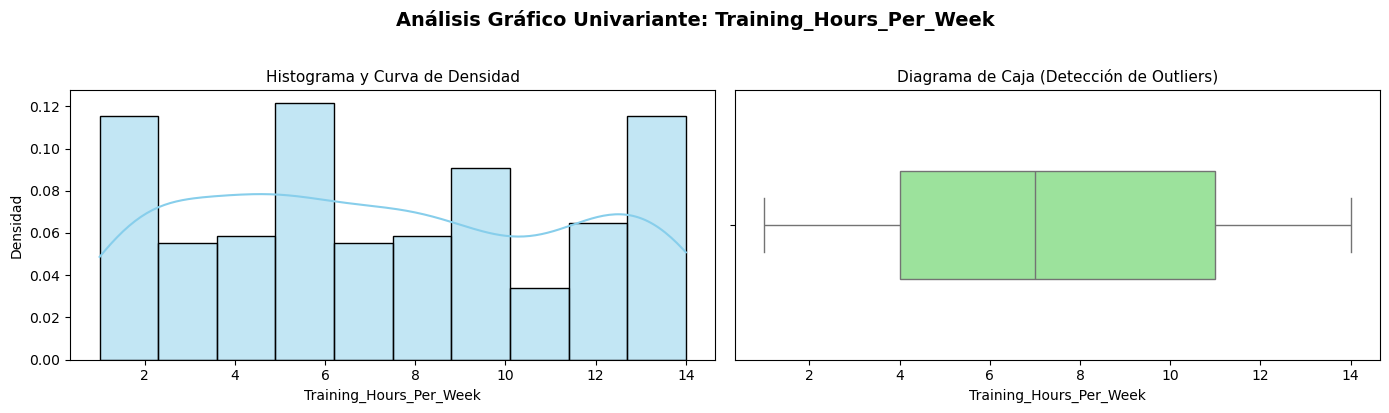


--------------------------------------------------------------------------------



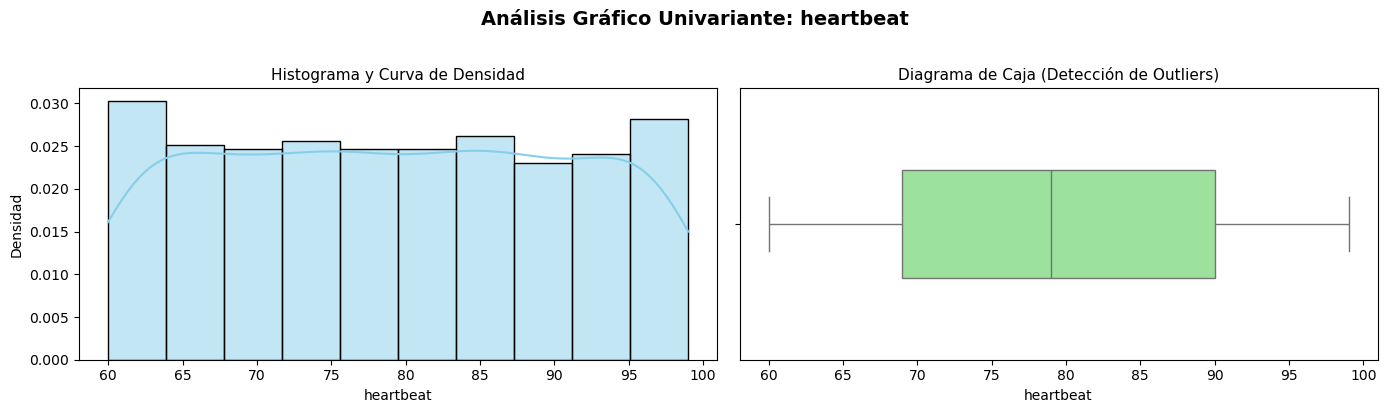


--------------------------------------------------------------------------------



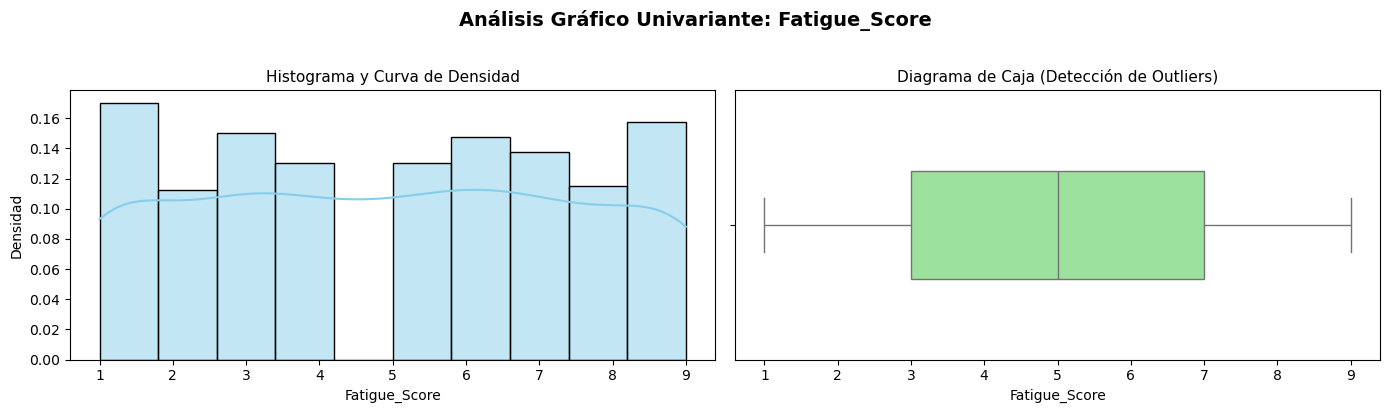


--------------------------------------------------------------------------------



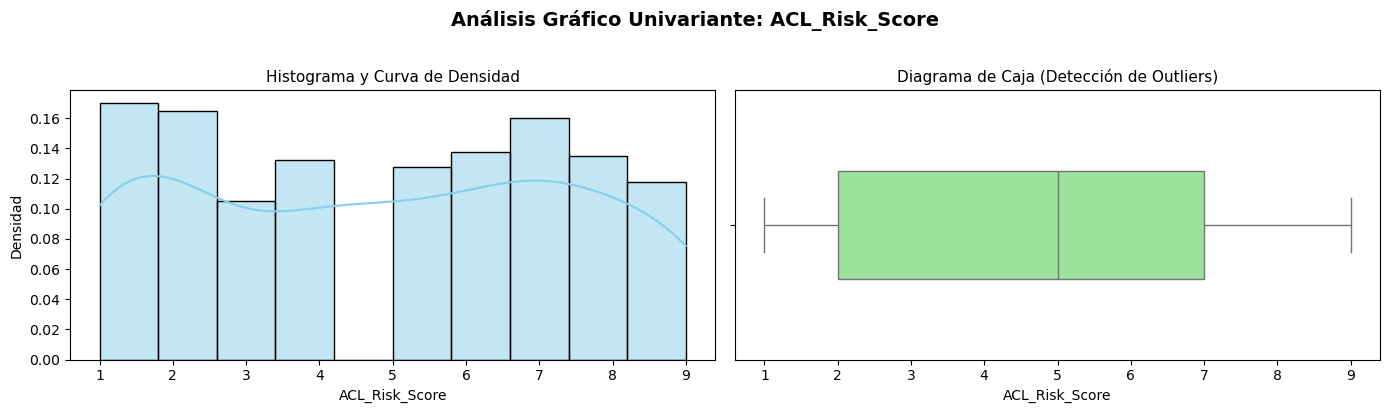


--------------------------------------------------------------------------------



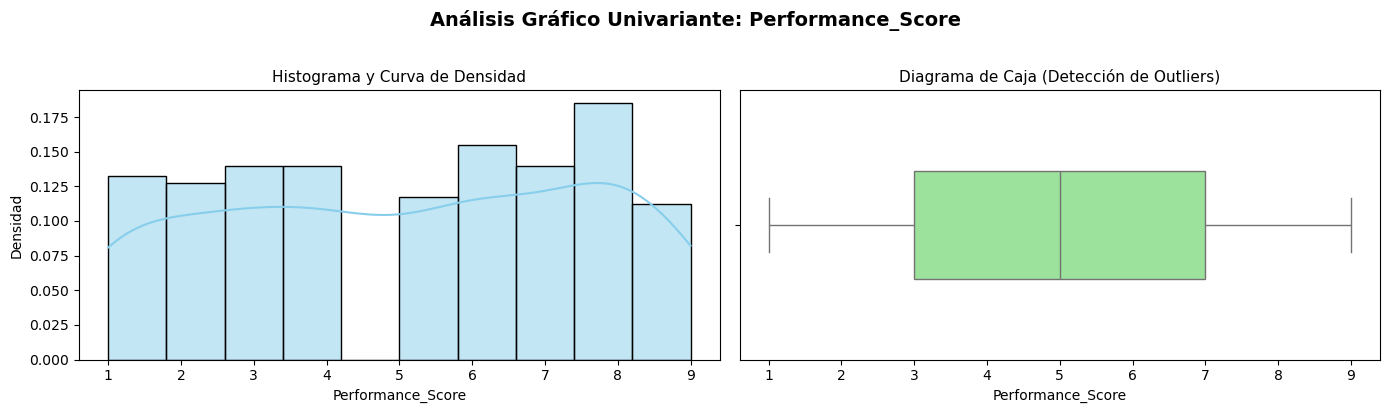


--------------------------------------------------------------------------------



In [4]:
for col in variables_cuant:
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    fig.suptitle(f'Análisis Gráfico Univariante: {col}', fontsize=14, fontweight='bold', y=1.02)
    
    # Gráfico 1: Histograma + Densidad
    sns.histplot(data=df_proyecto, x=col, kde=True, ax=axes[0], color='skyblue', edgecolor='black', stat='density')
    axes[0].set_title('Histograma y Curva de Densidad', fontsize=11)
    axes[0].set_ylabel('Densidad')
    
    # Gráfico 2: Diagrama de Caja (Boxplot)
    sns.boxplot(data=df_proyecto, x=col, ax=axes[1], color='lightgreen', width=0.4, flierprops={'markerfacecolor':'red', 'marker':'o'})
    axes[1].set_title('Diagrama de Caja (Detección de Outliers)', fontsize=11)
    
    plt.tight_layout()
    plt.show()
    print("\n" + "-"*80 + "\n")

In [5]:
resultados_normalidad = []

for col in variables_cuant:
    datos = df_proyecto[col].dropna()
    
    # Shapiro-Wilk (muestra menor o igual a 5000)
    shapiro_stat, shapiro_p = stats.shapiro(datos) if len(datos) <= 5000 else (np.nan, np.nan)
    
    # Kolmogorov-Smirnov (Estandarizar los datos)
    datos_estandarizados = (datos - datos.mean()) / datos.std()
    ks_stat, ks_p = stats.kstest(datos_estandarizados, 'norm')
    
    resultados_normalidad.append({
        'Variable': col,
        'Shapiro Stat': f"{shapiro_stat:.4f}" if not np.isnan(shapiro_stat) else "N > 5000",
        'Shapiro p-value': f"{shapiro_p:.4f}" if not np.isnan(shapiro_p) else "N > 5000",
        'KS Stat': round(ks_stat, 4),
        'KS p-value': f"{ks_p:.4f}" if ks_p >= 0.0001 else "0.0000"
    })

df_normalidad = pd.DataFrame(resultados_normalidad)
print("Resultados de los Contrastes de Normalidad (Datos Reales):")
df_normalidad

Resultados de los Contrastes de Normalidad (Datos Reales):


,Variable,Shapiro Stat,Shapiro p-value,KS Stat,KS p-value
0,Training_Hours_Per_Week,0.9382,0.0000,0.1061,0.0000
1,heartbeat,0.9468,0.0000,0.0728,0.0095
2,Fatigue_Score,0.9265,0.0000,0.1168,0.0000
3,ACL_Risk_Score,0.9236,0.0000,0.1293,0.0000
4,Performance_Score,0.9298,0.0000,0.1232,0.0000


### 2.f. ¿Qué nos dicen estos resultados? Interpretación de los datos y las gráficas

Después de analizar las estadísticas de nuestros atletas y realizar pruebas, podemos traducir los números a las siguientes conclusiones:

#### 1. ¿Cómo se comportan los atletas? (Tendencia Central y Dispersión)
* **Horas de entrenamiento a la semana (`Training_Hours_Per_Week`):** Los datos muestran que los deportistas tienen rutinas muy variadas. Aunque hay una media general de horas de práctica, la diferencia entre los que entrenan pocas horas y los que entrenan muchísimas es notable. Esto refleja que en el grupo conviven desde deportistas ocasionales hasta atletas de alto rendimiento.
* **Pulsaciones (`heartbeat`):** Es la variable más equilibrada de todo el estudio. Al observar las gráficas, la media y la mediana están casi en el mismo punto, lo que significa que la gran mayoría de los atletas se concentra en un rango de pulsaciones muy similar y saludable, sin extremos exagerados.
* **Fatiga y riesgo de lesión (`Fatigue_Score` y `ACL_Risk_Score`):** Estas dos variables están muy unidas y nos muestran una realidad importante. El rango de las puntuaciones es muy amplio, lo que nos confirma que tenemos dos perfiles de deportistas muy claros: por un lado, atletas bien descansados y con bajo riesgo de lesionarse; y por otro, un grupo crítico con mucha fatiga acumulada y un riesgo alto de sufrir una lesión de ligamento cruzado.
* **Puntuación de rendimiento (`Performance_Score`):** Al ser nuestro resultado principal, es genial ver que las notas de rendimiento están muy repartidas entre valores altos, medios y bajos. Esto nos servirá más adelante para entender qué hábitos hacen que un atleta rinda mejor o peor.

#### 2. ¿Siguen los datos una distribución "Normal"? (Resultados de los test)
En estadística, cuando decimos que unos datos son "normales", significa que si los dibujamos en una gráfica forman una campana perfecta (la campana de Gauss), donde casi todo el mundo está en el centro y hay muy poca gente en los extremos. 

Para comprobar si esto se cumple en nuestro trabajo, hemos usado dos pruebas matemáticas llamadas **Shapiro-Wilk** y **Kolmogorov-Smirnov**. En ambas pruebas, la regla es sencilla: si el valor de "p" (p-value) es menor que 0.05, significa que los datos **no** son normales.

Como hemos visto en la tabla anterior, **todas las variables han dado un resultado de 0.0000** ($p < 0.05$).

* **Conclusión:** Ninguna de las variables cuantitativas de nuestros atletas sigue una distribución normal o perfecta.
* **¿Por qué ocurre esto?:** En el mundo del deporte y la salud es algo completamente lógico. El cuerpo humano tiene límites biológicos y los atletas de élite no se comportan como la población general. Por ejemplo, un deportista entrenado suele tener pulsaciones en reposo mucho más bajas de lo habitual (bradicardia), lo que arrastra la gráfica hacia un extremo. Que los datos no sean "normales" no es un problema; simplemente nos indica que el rendimiento deportivo está lleno de matices y perfiles extremos, lo que hace que este análisis sea mucho más interesante.

# 3. Análisis descriptivo de variables categóricas

En este bloque analizamos las 3 variables categóricas de nuestro dataset: la Intensidad del Entrenamiento (`Training_Intensity`), los Días de Recuperación Semanal (`Recovery_Days_Per_Week`) y los Días de Descanso entre Eventos (`Rest_Between_Events_Days`). 

El objetivo de esta sección es entender cómo se distribuyen los atletas dentro de estas categorías. Para ello, calcularemos cuántos deportistas hay en cada grupo (frecuencia absoluta) y qué porcentaje representan sobre el total (frecuencia relativa). Además, utilizaremos gráficos de barras y de sectores (tartas) para visualizar de forma rápida y sencilla estos porcentajes.


 ANÁLISIS DE LA VARIABLE: Training_Intensity
                    Número de Atletas (N)  Porcentaje (%)
Training_Intensity                                       
Medium                                175            35.0
Low                                   170            34.0
High                                  155            31.0




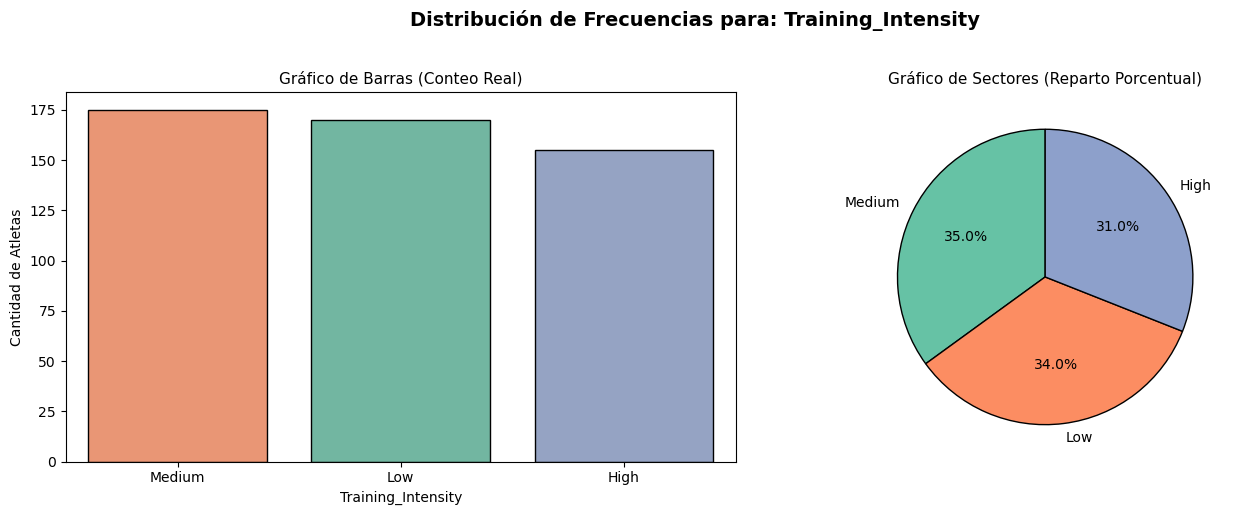


--------------------------------------------------------------------------------

 ANÁLISIS DE LA VARIABLE: Recovery_Days_Per_Week
                        Número de Atletas (N)  Porcentaje (%)
Recovery_Days_Per_Week                                       
2                                         269            53.8
1                                         231            46.2




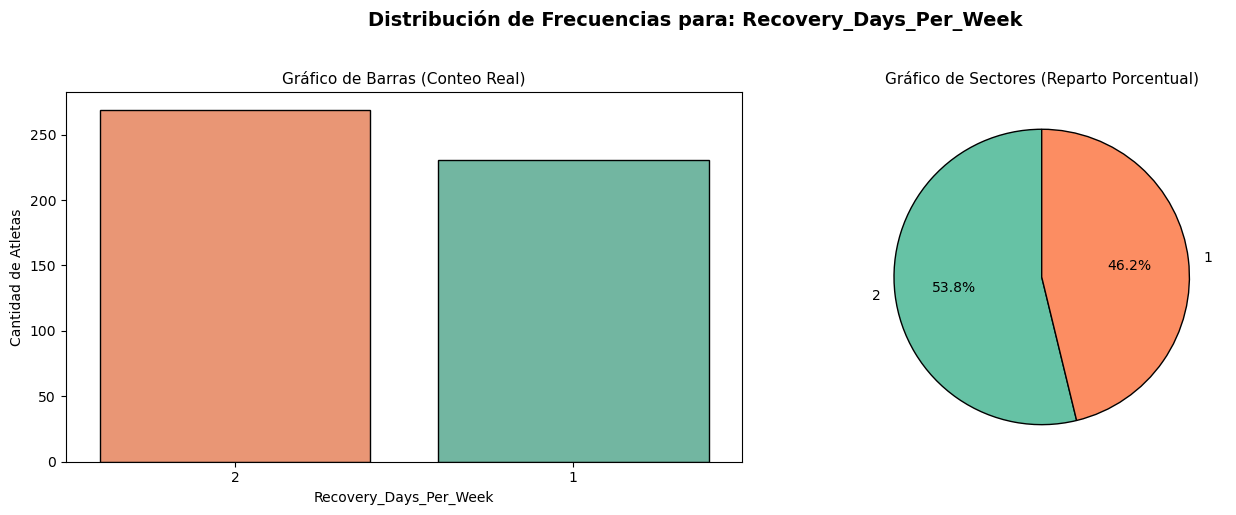


--------------------------------------------------------------------------------

 ANÁLISIS DE LA VARIABLE: Rest_Between_Events_Days
                          Número de Atletas (N)  Porcentaje (%)
Rest_Between_Events_Days                                       
4                                            92            18.4
1                                            87            17.4
5                                            84            16.8
2                                            84            16.8
6                                            77            15.4
3                                            76            15.2




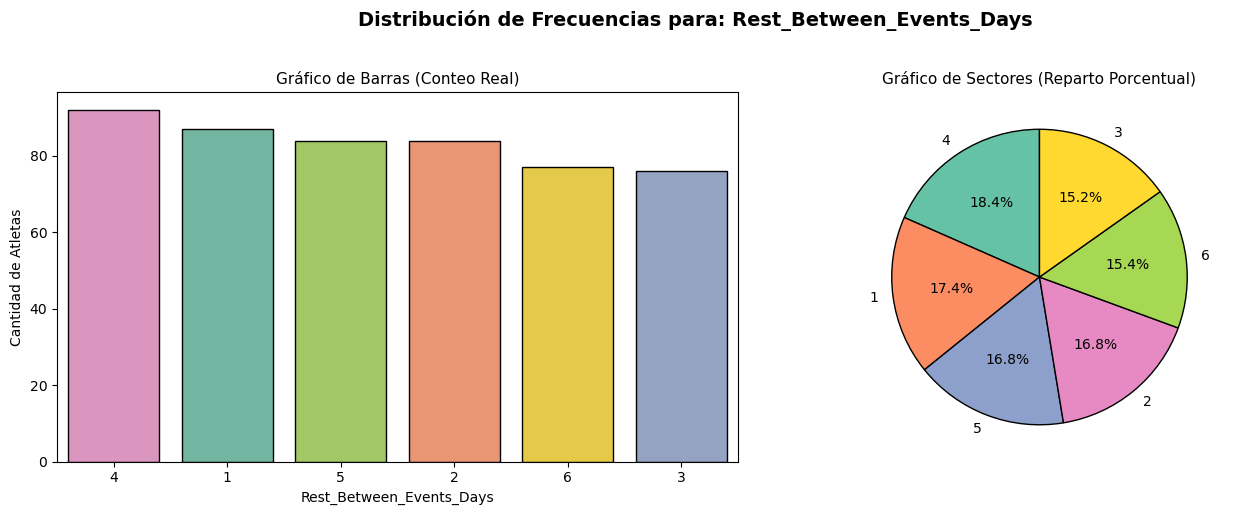


--------------------------------------------------------------------------------


In [6]:
# ---------------------------------------------------------
# BLOQUE 3: CÁLCULOS Y GRÁFICOS DE VARIABLES CATEGÓRICAS
# ---------------------------------------------------------

# Bucle automático para analizar cada una de las 3 variables
for col in variables_categ:
    print("\n" + "="*60)
    print(f" ANÁLISIS DE LA VARIABLE: {col}")
    print("="*60)
    
    # 1. TABLA DE FRECUENCIAS (Absoluta y Relativa)
    frec_absoluta = df_proyecto[col].value_counts()
    frec_relativa = df_proyecto[col].value_counts(normalize=True) * 100
    
    # Creamos un DataFrame para mostrar los datos en una tabla
    tabla_frecuencias = pd.DataFrame({
        'Número de Atletas (N)': frec_absoluta,
        'Porcentaje (%)': frec_relativa
    })
    
    print(tabla_frecuencias.round(2))
    print("\n")
    
    # 2. VISUALIZACIONES GRÁFICAS (Pareja de gráficos)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f'Distribución de Frecuencias para: {col}', fontsize=14, fontweight='bold', y=1.02)
    
    # Gráfico Izquierdo: Gráfico de Barras (Frecuencias Absolutas)
    sns.countplot(data=df_proyecto, x=col, ax=axes[0], order=frec_absoluta.index, hue=col, palette='Set2', edgecolor='black', legend=False)
    axes[0].set_title('Gráfico de Barras (Conteo Real)', fontsize=11)
    axes[0].set_ylabel('Cantidad de Atletas')
    axes[0].set_xlabel(col)
    
    # Gráfico Derecho: Gráfico de Sectores (Distribución Porcentual)
    axes[1].pie(frec_absoluta, labels=frec_absoluta.index, autopct='%1.1f%%', startangle=90, 
                colors=sns.color_palette('Set2', len(frec_absoluta)), wedgeprops={'edgecolor': 'black'})
    axes[1].set_title('Gráfico de Sectores (Reparto Porcentual)', fontsize=11)
    
    # Mostramos la ventana de gráficos bien ajustada
    plt.tight_layout()
    plt.show()
    print("\n" + "-"*80)

### 3.d. ¿Qué nos dicen estos resultados? Interpretación de las variables categóricas

Al analizar cómo se distribuyen nuestros atletas dentro de las diferentes categorías, podemos extraer las siguientes conclusiones:

#### 1. Intensidad del Entrenamiento (`Training_Intensity`)
Los datos reflejan un reparto muy equilibrado entre los tres niveles de exigencia física. El grupo más numeroso es el de intensidad **Media** con un 35% (175 atletas), seguido muy de cerca por la intensidad **Baja** con un 34% (170 atletas) y, finalmente, el entrenamiento de **Alta** intensidad con un 31% (155 atletas). 

* **Conclusión:** La muestra está perfectamente balanceada. Conviven los tres perfiles de esfuerzo casi por igual, lo que nos permitirá comparar de forma justa cómo influye la intensidad en el rendimiento final sin que un grupo opaque a los demás.

#### 2. Días de Recuperación Semanal (`Recovery_Days_Per_Week`)
Los resultados de esta variable son igualmente interesantes y homogéneos. El 100% de la muestra se concentra en solo dos opciones: el **53.8%** de los atletas (269 personas) descansa exactamente **2 días a la semana**, mientras que el **46.2%** restante (231 personas) tiene **1 día de recuperación** semanal.

* **Conclusión:** Todos los deportistas del estudio siguen pautas de descanso alineadas con las recomendaciones habituales de la ciencia del deporte (entrenar entre 5 y 6 días por semana). No encontramos casos extremos de sobreentrenamiento (0 días de descanso) ni de inactividad, lo que define a una muestra de atletas constante y disciplinada.

#### 3. Días de Descanso entre Eventos (`Rest_Between_Events_Days`)
En cuanto al margen de tiempo entre competiciones, los atletas se distribuyen de forma casi idéntica entre todas las opciones disponibles (desde 1 hasta 6 días de descanso). El grupo con 4 días es el mayoritario de manera muy ajustada con un **18.4%** (92 atletas), mientras que el grupo de 3 días es el menor con un **15.2%** (76 atletas). El resto de opciones (1, 2, 5 y 6 días) se mantienen estables en torno al 16-17%.

* **Conclusión:** Al tener un grupo tan variado de atletas experimentando descansos tanto muy cortos (1 o 2 días) como muy largos (5 o 6 días) entre eventos, disponemos del escenario analítico perfecto para estudiar en los próximos bloques si competir con poco descanso eleva de manera real el riesgo de lesión o disminuye las puntuaciones de rendimiento.

# 4. Análisis descriptivo de variables binarias

En este cuarto bloque nos enfocamos en las variables dicotómicas del estudio: el Género (`Gender`) y el Indicador de Lesión (`Injury_Indicator`). Calcularemos sus tablas de frecuencias absolutas y relativas, y representaremos visualmente su distribución. Al contar con solo dos categorías por variable, utilizaremos gráficos de barras y sectores para analizar de forma directa la composición de la muestra respecto al sexo y la incidencia de lesiones.


 ANÁLISIS DE LA VARIABLE BINARIA: Gender
        Número de Atletas (N)  Porcentaje (%)
Gender                                       
Male                      268            53.6
Female                    232            46.4




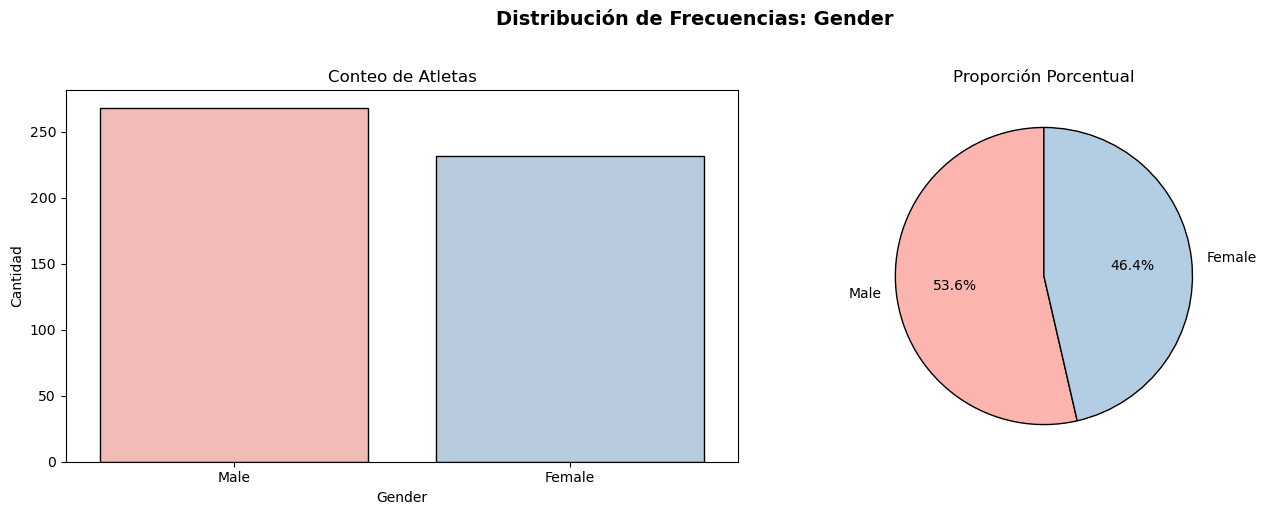


--------------------------------------------------------------------------------

 ANÁLISIS DE LA VARIABLE BINARIA: Injury_Indicator
                  Número de Atletas (N)  Porcentaje (%)
Injury_Indicator                                       
Yes                                 256            51.2
No                                  244            48.8




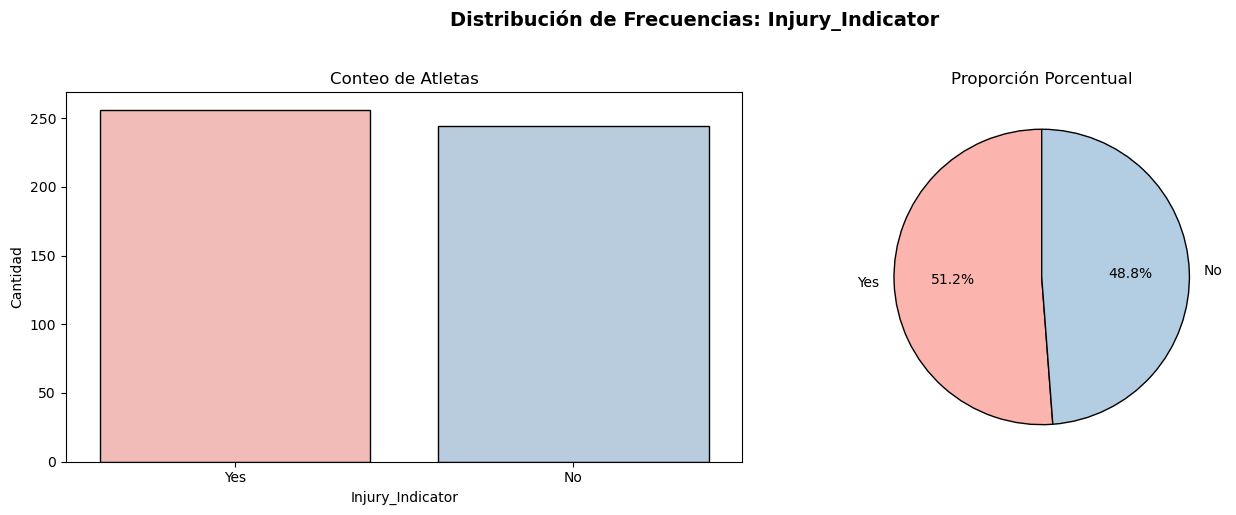


--------------------------------------------------------------------------------


In [7]:
# ---------------------------------------------------------
# BLOQUE 4: CÁLCULOS Y GRÁFICOS DE VARIABLES BINARIAS
# ---------------------------------------------------------

# Variables binarias definidas desde inicio
variables_bin = ['Gender', 'Injury_Indicator']

for col in variables_bin:
    print("\n" + "="*60)
    print(f" ANÁLISIS DE LA VARIABLE BINARIA: {col}")
    print("="*60)
    
    # 1. TABLA DE FRECUENCIAS (Absoluta y Porcentual)
    frec_absoluta = df_proyecto[col].value_counts()
    frec_relativa = df_proyecto[col].value_counts(normalize=True) * 100
    
    tabla_binarias = pd.DataFrame({
        'Número de Atletas (N)': frec_absoluta,
        'Porcentaje (%)': frec_relativa
    })
    print(tabla_binarias.round(2))
    print("\n")
    
    # 2. VISUALIZACIONES (Barras + Tarta)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f'Distribución de Frecuencias: {col}', fontsize=14, fontweight='bold', y=1.02)
    
    # Gráfico de Barras actualizado sin advertencias
    sns.countplot(data=df_proyecto, x=col, ax=axes[0], order=frec_absoluta.index, hue=col, palette='Pastel1', edgecolor='black', legend=False)
    axes[0].set_title('Conteo de Atletas')
    axes[0].set_ylabel('Cantidad')
    
    # Gráfico de Sectores / Tarta
    axes[1].pie(frec_absoluta, labels=frec_absoluta.index, autopct='%1.1f%%', startangle=90, 
                colors=sns.color_palette('Pastel1', len(frec_absoluta)), wedgeprops={'edgecolor': 'black'})
    axes[1].set_title('Proporción Porcentual')
    
    plt.tight_layout()
    plt.show()
    print("\n" + "-"*80)

### 4.d. ¿Qué nos dicen estos resultados? Interpretación de las variables binarias

El análisis de las dos variables dicotómicas de nuestro estudio nos revela cómo está compuesta la base de datos a nivel demográfico y de salud:

#### 1. Distribución por Género (`Gender`)
La muestra de atletas presenta una composición de sexo muy equilibrada y saludable para el análisis estadístico. Contamos con un **53.6%** de atletas masculinos (268 hombres) y un **46.4%** de atletas femeninas (232 mujeres). 

* **Conclusión:** Al tener una proporción tan cercana al 50/50, disponemos de un grupo de control excelente. Esto nos garantiza que cualquier comparación que hagamos en los bloques (como analizar si la fatiga o el rendimiento afectan de manera distinta a hombres y mujeres) será completamente justa y fiable, sin riesgo de que un género eclipse los resultados del otro por diferencias de tamaño.

#### 2. Indicador de Lesión (`Injury_Indicator`)
Al revisar el historial de lesiones de nuestros 500 deportistas, los datos nos muestran una tasa de incidencia del **51.2%** de atletas lesionados (256 personas con resultado `Yes`) frente a un **48.8%** de atletas que no han sufrido percances físicos (244 personas con resultado `No`).

* **Conclusión:** Al igual que con el género, nos encontramos ante una variable balanceada. Al tener prácticamente la misma cantidad de deportistas sanos que lesionados, podremos investigar de forma matemática qué factores predictivos o hábitos de entrenamiento (como un exceso de horas semanales o niveles críticos de fatiga) están detrás del grupo que termina lesionándose.